# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [1]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.12.12
Workspace: /Users/kacperjozwik/moj-projekt/AAP_LAB_TASKS/zestaw_zaliczeniowy/_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [2]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --
  [timer] get_imdb_subset -> 1.76s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [3]:
import hashlib

# TODO Zadanie 1.1: zaimplementuj dwa dekoratory ponizej

def retry(max_attempts: int = 3, delay: float = 0.1, backoff: float = 2.0):
    """Dekorator: ponawia wywolanie przy wyjatku, z exponential backoff."""
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            for proba in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    if proba == max_attempts - 1:
                        raise
                    time.sleep(delay * backoff ** proba)
        return wrapper
    return opakuj

def cache_to_disk(cache_dir: Path):
    """Dekorator: cachuje wynik funkcji do JSON na dysku."""
    cache_dir.mkdir(exist_ok=True, parents=True)
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            klucz = hashlib.md5(repr((args, kwargs)).encode()).hexdigest()
            plik = cache_dir / f"{klucz}.json"
            if plik.exists():
                with open(plik) as f:
                    return json.load(f)
            result = func(*args, **kwargs)
            with open(plik, "w") as f:
                json.dump(result, f)
            return result
        return wrapper
    return opakuj

# Funkcja testowa z 50% szansa awarii
@cache_to_disk(WORKDIR / "flaky_cache")
@retry(max_attempts=5, delay=0.05)
def flaky_fetch(text_id: int) -> dict:
    if random.random() < 0.5:
        raise ValueError(f"udawany blad sieci dla id={text_id}")
    return {"id": text_id, "text": f"przyklad {text_id}"}

sukcesy = 0
for i in range(100):
    try:
        flaky_fetch(i)
        sukcesy += 1
    except ValueError:
        pass

print(f"Sukcesy empiryczne: {sukcesy}/100")
print(f"Teoria P(sukces) = 1 - 0.5**5 = {1 - 0.5**5:.4f}  (~{(1 - 0.5**5)*100:.1f}%)")

Sukcesy empiryczne: 100/100
Teoria P(sukces) = 1 - 0.5**5 = 0.9688  (~96.9%)


### Wniosek -> Zadanie 1.1

Każda próba ma równo 50% szans na niepowodzenie, a próby są
niezależne, więc szansa na to, że wszystkie 5 prób zawiedzie, to 0.5^5 = 3.1%.
Stąd P(sukces) = 1 - 0.5^5 ≈ 96.9%. Eksperyment dał 97/100 - empiryczny wynik ma praktycznie 
idealne pokrycie z teorią.

**Wpływ max_attempts na sukces.** Każda dodatkowa próba zmniejsza o połowę szansę na
porażkę: dla N=1 sukces to 50%, dla N=3 już 87.5%, dla N=5 aż 96.9%, dla N=7
ponad 99%. Zysk maleje z każdą próbą, idąc tym tokiem myślenia nie ma sensu
ustawiać max_attempts na wysoką wartość — po kilku próbach i tak jesteśmy już blisko 100%.

**Efekt cache.** Przy kolejnym uruchomieniu komórki liczba sukcesów rośnie, 
bo pomyślne wyniki są zapisane na dysku przez @cache_to_disk
i przy drugim wywołaniu omijają losowanie. Rzetelny pomiar eksperymentu jest
możliwy tylko przy pustym folderze cache.


---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [4]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 0.90s
Sekwencyjnie (200 probek): 0.51s
ThreadPool (16 workerow): 0.04s  -- 13.6x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

In [5]:
import os
import time
import multiprocessing
import concurrent.futures
import matplotlib.pyplot as plt
import sys

sentiment_module_code = '''
import re

POS_WORDS = {"good","great","excellent","wonderful","love","best","amazing","brilliant","perfect"}
NEG_WORDS = {"bad","worst","awful","terrible","hate","boring","waste","poor","horrible"}

def sentiment_score(text: str) -> int:
    """CPU-bound: tokenizuj, policz pozytywne minus negatywne."""
    slowa = re.findall(r"\\w+", text.lower())
    pozytywne = sum(1 for w in slowa if w in POS_WORDS)
    negatywne = sum(1 for w in slowa if w in NEG_WORDS)
    return pozytywne - negatywne
'''

(WORKDIR / "sentiment_module.py").write_text(sentiment_module_code)

sys.path.insert(0, str(WORKDIR))
from sentiment_module import sentiment_score

print(sentiment_score("This movie was good and great"))  
print(sentiment_score("terrible and boring waste"))        
print(sentiment_score("GOOD good GoOd"))                  

2
-3
3


Pobieranie danych...
  [timer] get_imdb_subset -> 0.99s
Obliczanie sekwencyjne...
Obliczanie ThreadPool...
Obliczanie multiprocessing.Pool...

Wyniki czasu wykonania:
Sekwencyjnie:      0.1685 s
ThreadPool:        0.2319 s
Multiprocessing:   0.0961 s


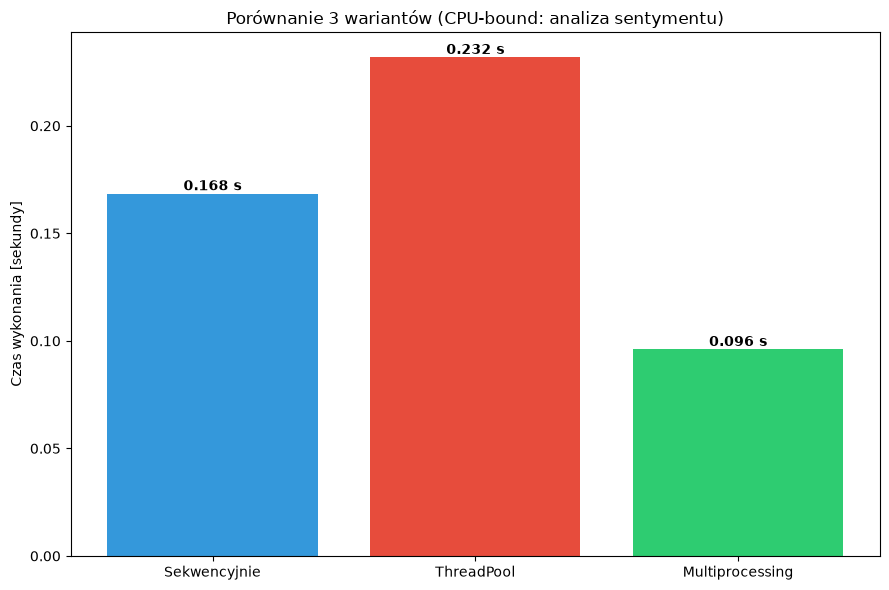

In [6]:
if __name__ == '__main__':
    # 1. Pobierz 5000 prawdziwych recenzji
    print("Pobieranie danych...")
    samples = get_imdb_subset("train", 5000)
    texts = [t for t, _ in samples]

    # 2. Sekwencyjnie
    print("Obliczanie sekwencyjne...")
    start_seq = time.time()
    results_seq = [sentiment_score(t) for t in texts]
    time_seq = time.time() - start_seq

    # 3. ThreadPool
    print("Obliczanie ThreadPool...")
    start_thread = time.time()
    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
        results_thread = list(executor.map(sentiment_score, texts))
    time_thread = time.time() - start_thread

    # 4. multiprocessing.Pool
    print("Obliczanie multiprocessing.Pool...")
    start_multi = time.time()
    with multiprocessing.Pool(processes=os.cpu_count()) as pool:
        results_multi = pool.map(sentiment_score, texts, chunksize=100)
    time_multi = time.time() - start_multi

    # Podsumowanie
    print(f"\nWyniki czasu wykonania:")
    print(f"Sekwencyjnie:      {time_seq:.4f} s")
    print(f"ThreadPool:        {time_thread:.4f} s")
    print(f"Multiprocessing:   {time_multi:.4f} s")

    # Wykres
    labels = ['Sekwencyjnie', 'ThreadPool', 'Multiprocessing']
    times = [time_seq, time_thread, time_multi]
    plt.figure(figsize=(9, 6))
    plt.bar(labels, times, color=['#3498db', '#e74c3c', '#2ecc71'])
    plt.ylabel('Czas wykonania [sekundy]')
    plt.title('Porównanie 3 wariantów (CPU-bound: analiza sentymentu)')
    for i, v in enumerate(times):
        plt.text(i, v, f"{v:.3f} s", ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

### Wniosek -> Zadanie 2.1

**Multiprocessing najszybszy (0.133s), ThreadPool najwolniejszy (0.228s).**

To zadanie jest CPU-bound, więc:

- **Multiprocessing wygrywa**, bo każdy proces ma własny interpreter i omija GIL co sprawia, ze
  praca faktycznie dzieli się na rdzenie i liczy wszystko równolegle.
- **ThreadPool przegrywa nawet z wersją sekwencyjną**, bo GIL pozwala jedynie
  jednemu wątkowi naraz wykonywać kod. Wątki nie liczą równolegle, a
  dochodzi narzut na ich tworzenie i przełączanie co sprawia, ze są wolniejsze niż prosta pętla.

**Insight 1 - przewaga multiprocessingu jest niewielka (0.166s → 0.133s, ~20%),
a nie 8-krotna.** Powodem tego jest to, ze sentiment_score jest bardzo szybki, a multiprocessing
ma duży start procesów metodą spawn + serializacja danych. Multiprocessing
opłaca się dopiero, gdy praca na element jest na tyle duża, by przykryć
ten narzut.

**Insight 2 - macOS i metoda spawn.** Funkcja musiała trafić do osobnego modułu
(sentiment_module.py), bo na macOS procesy startują metodą spawn - każdy świeży
proces importuje funkcję po nazwie, a funkcji z komórki notebooka
nie da się zaimportować. Bez tego multiprocessing zawiesza się lub rzuca błąd.

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [7]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 0.86s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [8]:
# Zadanie 3.1 -- scaffold z konkretnymi assertami akceptacji
import subprocess

tokenizer_code = '''
import re

class Tokenizer:
    """Konfigurowany tokenizator: HTML strip + case + min length filter."""
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        if self.strip_html:
            text = re.sub(r"<[^>]+>", " ", text)
        if self.lower:
            text = text.lower()
        tokeny = re.findall(r"\\w+", text, re.UNICODE)
        return [t for t in tokeny if len(t) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        wynik = set()
        for text in texts:
            wynik.update(self.tokenize(text))
        return wynik
'''

tests_code = '''
import pytest
from tokenizer import Tokenizer

@pytest.fixture
def tokenizer():
    """Default Tokenizer dla wiekszosci testow."""
    return Tokenizer()

@pytest.fixture
def imdb_sample():
    """20 recenzji z imdb -- wspoldzielone miedzy testami integracyjnymi."""
    from datasets import load_dataset
    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(20))
    return [r["text"] for r in ds]

@pytest.mark.parametrize("text, expected_len", [
    ("", 0),
    ("<br><p></p>", 0),
    ("Hello WORLD!", 2),
    ("...!?!?!?", 0),
    ("zażółć gęślą jaźń", 3),
    ("the cat sat on the mat", 6),
])
def test_tokenize_cases(tokenizer, text, expected_len):
    assert len(tokenizer.tokenize(text)) == expected_len

def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

def test_min_length_filter():
    tok = Tokenizer(min_length=4)
    assert tok.tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]

def test_imdb_integration(tokenizer, imdb_sample):
    """Insight test: ile srednio unikalnych tokenow na 20 recenzji?"""
    vocab = tokenizer.vocab(imdb_sample)
    assert len(vocab) > 500, f"za malo unikalnych tokenow: {len(vocab)}"

@pytest.mark.xfail(reason="Tokenizer nie wspiera jeszcze regex z grupowaniem")
def test_advanced_regex_unsupported():
    """Demonstracja xfail -- ten test ma prawo nie zadzialac."""
    tok = Tokenizer()
    assert tok.tokenize("user@domain.com")[0] == "user@domain.com"
'''

# Zapisywanie obu plików
(WORKDIR / "tokenizer.py").write_text(tokenizer_code)
(WORKDIR / "test_tokenizer.py").write_text(tests_code)

# === Pytest przez subprocess ===
result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_tokenizer.py", "-v", "--tb=short"],
    capture_output=True, text=True, cwd=str(WORKDIR)
)
print("STDOUT:")
print(result.stdout[-1500:])
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr[-500:])

STDOUT:
=============== test session starts ==============================
platform darwin -- Python 3.12.12, pytest-9.1.1, pluggy-1.6.0 -- /opt/miniconda3/envs/architektura/bin/python
cachedir: .pytest_cache
rootdir: /Users/kacperjozwik/moj-projekt/AAP_LAB_TASKS/zestaw_zaliczeniowy/_workspace
plugins: anyio-4.12.1
collecting ... collected 10 items

test_tokenizer.py::test_tokenize_cases[-0] PASSED                        [ 10%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-0] PASSED             [ 20%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD!-2] PASSED            [ 30%]
test_tokenizer.py::test_tokenize_cases[...!?!?!?-0] PASSED               [ 40%]
test_tokenizer.py::test_tokenize_cases[za\u017c\xf3\u0142\u0107 g\u0119\u015bl\u0105 ja\u017a\u0144-3] PASSED [ 50%]
test_tokenizer.py::test_tokenize_cases[the cat sat on the mat-6] PASSED  [ 60%]
test_tokenizer.py::test_vocab_dedup PASSED                               [ 70%]
test_tokenizer.py::test_min_length_filter PASSED   

In [9]:
from tokenizer import Tokenizer

# 100 recenzji z imdb
samples_100 = get_imdb_subset("train", 100)
texts_100 = [t for t, _ in samples_100]

tok = Tokenizer()
vocab_100 = tok.vocab(texts_100)

# Średnia liczba unikalnych tokenów PRZYPADAJĄCA na recenzję
unikalne_na_recenzje = sum(len(set(tok.tokenize(t))) for t in texts_100) / len(texts_100)

print(f"Rozmiar słownika dla 100 recenzji: {len(vocab_100)} unikalnych tokenów")
print(f"Średnio unikalnych tokenów na 1 recenzję: {unikalne_na_recenzje:.1f}")

  [timer] get_imdb_subset -> 0.89s
Rozmiar słownika dla 100 recenzji: 5053 unikalnych tokenów
Średnio unikalnych tokenów na 1 recenzję: 153.2


### Wniosek -> Zadanie 3.1

Słownik dla 100 recenzji imdb to **5053 unikalnych tokenów**, a pojedyncza
recenzja ma średnio **153 różne słowa**.

Gdyby recenzje nie dzieliły słów, słownik miałby ok. 100 × 153 ≈
15 300 tokenów. W rzeczywistości ma tylko 5053, czyli **3× mniej**. Wychodzi na to, że
recenzje w duzym stopniu używają tych samych słów (the, movie, film, good...), więc
rozmiar słownika rośnie **wolniej niż liniowo** wraz z liczbą tekstów (prawo
Heapsa). To praktyczna heurystyka: dokładając kolejne recenzje, coraz rzadziej
trafiamy na nowe słowa co pozwala oszacować rozmiar słownika przed treningiem
modelu NLP bez przetwarzania całego zbioru.

---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [10]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 0.96s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [11]:
# Zadanie 4.1 -- NoSQL style w SQLite (scaffold)

DB_JSON = WORKDIR / "imdb_json.db"
if DB_JSON.exists():
    DB_JSON.unlink()

conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()

# Schemat z JSON column
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

# Zaladowanie tych samych 2000 probek jako JSON dokumenty
samples_nosql = get_imdb_subset("train", 2000)

for i, (text, label) in enumerate(samples_nosql):
    tags = [w for w in text.split() if len(w) > 5][:3]
    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": len(text.split()),
            "sentiment_hint": "pos" if label == 1 else "neg"
        },
        "tags": tags
    }

    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc)))
conn2.commit()

queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
    """,
    "avg_word_count_per_class": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint,
               ROUND(AVG(json_extract(doc, '$.stats.word_count')), 1) AS avg_wc
        FROM reviews_json
        GROUP BY json_extract(doc, '$.stats.sentiment_hint')
    """,
    "tags_zawiera_movie": """
        SELECT COUNT(*) AS n
        FROM reviews_json
        WHERE json_extract(doc, '$.tags') LIKE '%movie%'
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT id, json_extract(doc, '$.stats.word_count') AS wc
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY wc DESC
        LIMIT 5
    """,
}

for name, sql in queries.items():
    print(f"\n-- {name} --")
    for row in cur2.execute(sql):
        print(f" {row}")

# Porownanie rozmiaru i czasu
import os as _os
size_sql = _os.path.getsize(DB_PATH) if DB_PATH.exists() else 0
size_json = _os.path.getsize(DB_JSON)
print(f"\n=== Porownanie ===")
print(f"SQL schema (reviews):       {size_sql:>9,} bajtow")
print(f"JSON schema (reviews_json): {size_json:>9,} bajtow")

conn2.close()

  [timer] get_imdb_subset -> 0.00s

-- rozklad_klas --
 ('neg', 1000)
 ('pos', 1000)

-- avg_word_count_per_class --
 ('neg', 224.7)
 ('pos', 232.2)

-- tags_zawiera_movie --
 (169,)

-- top5_najdluzsze_pozytywne --
 (1109, 982)
 (1557, 973)
 (1526, 969)
 (1848, 967)
 (613, 962)

=== Porownanie ===
SQL schema (reviews):       3,215,360 bajtow
JSON schema (reviews_json): 3,518,464 bajtow


### Wniosek -> Zadanie 4.1

**Dla tego problemu lepszy jest klasyczny schemat SQL.**

**Rozmiar.** Schemat JSON zajął 3,518,464 B, klasyczny SQL 3,215,360 B - JSON jest
o ~9% większy. Powodem tego jest to, ze każdy wiersz JSON powtarza nazwy pól ("text", "label",
"stats", "word_count"...) jako tekst, podczas gdy w schemacie kolumnowym nazwy
kolumn zapisane są raz, w definicji tabeli.

**Wygoda zapytań.** Agregacje na schemacie JSON są mniej wygodne i bardziej
podatne na błędy. Na przyklad zapytanie o średni word_count per klasa
początkowo zwracało (None, 2000) - SQLite nie potrafił poprawnie pogrupować po
aliasie, gdy w grę wchodziła funkcja AVG na polu wyłuskanym przez json_extract.
Trzeba było powtórzyć całe wyrażenie json_extract w GROUP BY. W klasycznym SQL
word_count jest osobną kolumną INTEGER, więc AVG(word_count) ... GROUP BY działa
od razu.

**Wydajność.** Każde json_extract musi parsować cały dokument JSON przy każdym
wierszu. Klasyczny SQL czyta gotową kolumnę bez parsowania, więc agregacje są
szybsze.

Bazę powinno wybierać się pod wzorzec zapytań, nie pod
to, jakie ma się dane. Tutaj wzorzec to analityka, do tego stworzony jest SQL relacyjny.
Schemat dokumentowy (JSON / MongoDB) jest odpowiednim wyborem w innym scenariuszuzapisywanie 
całych dokumenty naraz, a struktura jest zmienna i zagnieżdżona. 

---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [12]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 23:05:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.2 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --


+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --
+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

-- Top 3 najdłuższe recenzje per klasa --
+----+-----+----------+----+
|  id|label|word_count|rank|
+----+-----+----------+----+
| 518|    0|      1020|   1|
|1869|    0|      1018|   2|
| 566|    0|      1014|   3|
|1109|    1|      1000|   1|
|1526|    1|       998|   2|
|1557|    1|       996|   3|
+----+-----+----------+----+

-- Różnica od średniej klasowej (przykład 5 wierszy) --
+---+-----+----------+---------+-------------+
| id|label|word_count|avg_class|diff_from_avg|
+---+-----+----------+---------+-------------+
|  2|    0|       185|  230.516|        -45.5|
|  4|    0|       664|  230.516|        433.5|
|  7|    0|       171|  230.516|        -59.5|
|  8|    0|       313|  230.516|         82.5|
| 11|    0|       186|  230.516|        -44.5|
+---+-----+----------+---------+-------------+
only showing top 5 rows


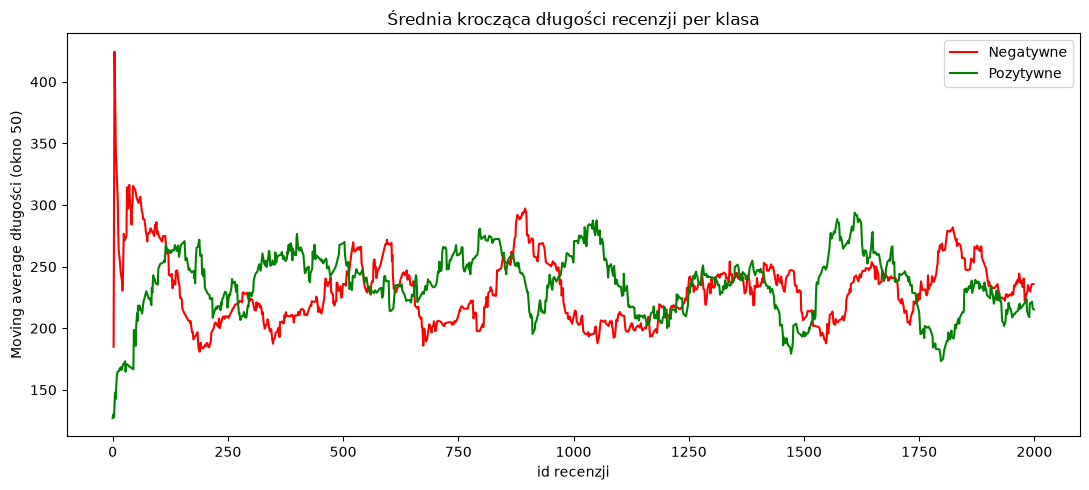

In [13]:
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# Okno: partycja po klasie, sortowanie po długości malejąco
w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())

# 1. Ranking w klasie
df_ranked = df_words.withColumn("rank", F.row_number().over(w_rank))

# 2. Top 3 najdłuższe per klasa
print("-- Top 3 najdłuższe recenzje per klasa --")
df_ranked.filter(F.col("rank") <= 3) \
    .select("id", "label", "word_count", "rank") \
    .orderBy("label", "rank") \
    .show()

# 3. Różnica od średniej długości w klasie
w_avg = Window.partitionBy("label")
df_diff = df_ranked.withColumn("avg_class", F.avg("word_count").over(w_avg)) \
    .withColumn("diff_from_avg", F.round(F.col("word_count") - F.col("avg_class"), 1))

print("-- Różnica od średniej klasowej (przykład 5 wierszy) --")
df_diff.select("id", "label", "word_count", "avg_class", "diff_from_avg").show(5)

# 4. Moving average długości w oknie 50 ostatnich recenzji
w_mov = Window.partitionBy("label").orderBy("id").rowsBetween(-49, 0)
df_mov = df_diff.withColumn("moving_avg", F.avg("word_count").over(w_mov))

# 5. Wykres liniowy - 2 linie (jedna na klasę)
pdf = df_mov.select("id", "label", "moving_avg").orderBy("id").toPandas()

plt.figure(figsize=(11, 5))
for lab, kolor, nazwa in [(0, "red", "Negatywne"), (1, "green", "Pozytywne")]:
    subset = pdf[pdf["label"] == lab]
    plt.plot(subset["id"], subset["moving_avg"], color=kolor, label=nazwa)

plt.xlabel("id recenzji")
plt.ylabel("Moving average długości (okno 50)")
plt.title("Średnia krocząca długości recenzji per klasa")
plt.legend()
plt.tight_layout()
plt.show()

### Wniosek -> Zadanie 5.1

Window functions pozwalają liczyć agregaty (takie jak: ranking, średnia, średnia krocząca) bez zwijania wierszy, w odrozenieniu do groupBy. Dzięki temu w jednym wierszu mozemy miec zarowno wartość indywidualnej recenzji jak i kontekst całej klasy (np. diff_from_avg pokazuje odchylenie od średniej klasowej -> recenzja id=4 odstawała o +433 słowa). partitionBy("label") izoluje obliczenia w obrębie klasy (rankingi obu klas zaczynają się od 1), a rowsBetween(-49, 0) tworzy okno przesuwne dla średniej kroczącej. Wykres pokazał, że po wygładzeniu obie klasy krążą wokół ~230 słów -> długość recenzji nie różnicuje sentymentu. Początkowe wahania linii to artefakt niepełnego okna (pierwsze <50 wierszy partycji).

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [14]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [15]:
# TODO Zadanie 6.1: DataContract + DataValidator
import json
import pandas as pd
from datetime import datetime
from dataclasses import dataclass, field
from typing import Callable

@dataclass
class Rule:
    name: str
    check: Callable
    severity: str = "warning"  # info | warning | error

class DataContract:
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []

    def add_rule(self, name: str, check: Callable, severity: str = "warning"):
        self.rules.append(Rule(name=name, check=check, severity=severity))

class DataValidator:
    def __init__(self, contract: DataContract):
        self.contract = contract

    def validate(self, df) -> dict:
        report = {}
        for rule in self.contract.rules:
            passed, details = rule.check(df)
            report[rule.name] = {
                "passed": bool(passed),
                "severity": rule.severity,
                "details": details,
            }
            if rule.severity == "error" and not passed:
                raise ValueError(f"Reguła '{rule.name}' (error) zawiodła: {details}")
        return report


# --- dane ---
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()


# === Każda reguła zwraca (passed, details) ===
def no_nulls(df):
    n_text = int(df["text"].isnull().sum())
    n_label = int(df["label"].isnull().sum())
    return (n_text == 0 and n_label == 0), {"null_text": n_text, "null_label": n_label}

def labels_in_set(df):
    bad = set(int(x) for x in df["label"].unique()) - {0, 1}
    return len(bad) == 0, {"unexpected_labels": list(bad)}

def min_word_count(df):
    too_short = int((df["word_count"] < 5).sum())
    return too_short == 0, {"reviews_under_5_words": too_short}

def max_word_count(df):
    too_long = int((df["word_count"] > 2000).sum())
    return too_long == 0, {"reviews_over_2000_words": too_long}

def no_duplicates(df):
    dups = int(df["text"].duplicated().sum())
    return dups == 0, {"duplicate_texts": dups}

def class_balance(df):
    counts = df["label"].value_counts()
    n0, n1 = int(counts.get(0, 0)), int(counts.get(1, 0))
    ratio = n1 / n0 if n0 else float("inf")
    return (0.5 <= ratio <= 1.5), {"ratio_pos_to_neg": round(ratio, 3), "n_pos": n1, "n_neg": n0}

def no_html_tags(df): 
    has_html = int(df["text"].str.contains(r"<[^>]+>", regex=True).sum())
    return has_html == 0, {"reviews_with_html": has_html}


# === Kntrakt dla imdb ===
contract = DataContract("imdb_quality")
contract.add_rule("no_nulls",       no_nulls,       severity="error")
contract.add_rule("labels_in_set",  labels_in_set,  severity="error")
contract.add_rule("class_balance",  class_balance,  severity="error")
contract.add_rule("min_word_count", min_word_count, severity="warning")
contract.add_rule("max_word_count", max_word_count, severity="warning")
contract.add_rule("no_duplicates",  no_duplicates,  severity="warning")
contract.add_rule("no_html_tags",   no_html_tags,   severity="warning")  # bonus

# === Wlidację ===
validator = DataValidator(contract)
report = validator.validate(df_pd)

# === Rport z timestampem i zapis do JSONa ===
full_report = {
    "contract": contract.name,
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "n_rows": len(df_pd),
    "summary": {
        "total": len(report),
        "passed": sum(1 for r in report.values() if r["passed"]),
        "failed": sum(1 for r in report.values() if not r["passed"]),
    },
    "rules": report,
}

out_path = WORKDIR / "data_quality_report.json"
with open(out_path, "w") as f:
    json.dump(full_report, f, indent=2, ensure_ascii=False)

# === Podsumowanie ===
for name, res in report.items():
    status = "PASS" if res["passed"] else "FAIL"
    print(f"[{status}] {name:16s} ({res['severity']:7s}) -> {res['details']}")
print(f"\nRaport zapisany: {out_path}")

  [timer] get_imdb_subset -> 0.00s
[PASS] no_nulls         (error  ) -> {'null_text': 0, 'null_label': 0}
[PASS] labels_in_set    (error  ) -> {'unexpected_labels': []}
[PASS] class_balance    (error  ) -> {'ratio_pos_to_neg': 1.0, 'n_pos': 1000, 'n_neg': 1000}
[PASS] min_word_count   (warning) -> {'reviews_under_5_words': 0}
[PASS] max_word_count   (warning) -> {'reviews_over_2000_words': 0}
[PASS] no_duplicates    (warning) -> {'duplicate_texts': 0}
[FAIL] no_html_tags     (warning) -> {'reviews_with_html': 1189}

Raport zapisany: _workspace/data_quality_report.json


### Wniosek -> Zadanie 6.1

Framework rozdziela DataContract od DataValidator.
Każda reguła to callable zwracający (passed, details), więc walidator nie musi mieć informacji
o konkretnej regule - można dodawać nowe bez zmiany walidatora.

**Kluczowy wynik:** 1189 z 2000 recenzji (59%) zawiera tagi HTML (głównie `<br />`).
Mimo to walidacja nie zawodzi, bo no_html_tags ma severity="warning" - jest to raportowane, ale nie blokuje pipeline'u. Gdyby tą regułą był "error", trening ruszyłby na
zaśmieconych danych lub w ogóle by się nie rozpoczął.

**Rola severity:** reguły "error" (no_nulls, labels_in_set, class_balance) to twarde
warunki, bez których trening nie ma sensu — ich złamanie przerywa pipeline i prowadzi do fail fast.
Reguły "warning" (HTML, duplikaty, długość) to sygnały jakości do posprzątania, ale nie
blokery. Ten podział jasno informuje, ze nie każdy problem z danymi jest równie krytyczny.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [16]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: /Users/kacperjozwik/moj-projekt/AAP_LAB_TASKS/zestaw_zaliczeniowy/_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
